In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('college_student_placement_dataset.csv')
df.head(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
5,CLG0015,96,5.26,5.32,7,No,5,8,0,No
6,CLG0071,123,6.68,6.58,5,No,7,8,2,Yes
7,CLG0096,111,8.77,8.76,7,No,3,1,2,Yes
8,CLG0097,92,6.47,6.33,9,No,7,8,5,No
9,CLG0057,108,8.82,8.60,4,No,5,9,1,No


In [3]:
# Get dimensions
rows = df.shape[0]
attributes = df.shape[1]

print(f"Number of rows: {rows}")
print(f"Number of attributes: {attributes}")
df.shape

Number of rows: 10000
Number of attributes: 10


(10000, 10)

In [4]:
numeric_count = len(df.select_dtypes(include=['number']).columns)

# Count categorical attributes (objects, strings, categories)
categorical_count = len(df.select_dtypes(exclude=['number']).columns)

print(f"Numeric attributes: {numeric_count}")
print(f"Categorical attributes: {categorical_count}")

Numeric attributes: 7
Categorical attributes: 3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 664.1+ KB


In [6]:
# Handle missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
# Encode categorical columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [8]:
# Features and target
# Assuming last column is target/class column
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [9]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Create Decision Tree model
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

In [11]:
# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)


In [12]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[1674    0]
 [   0  326]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



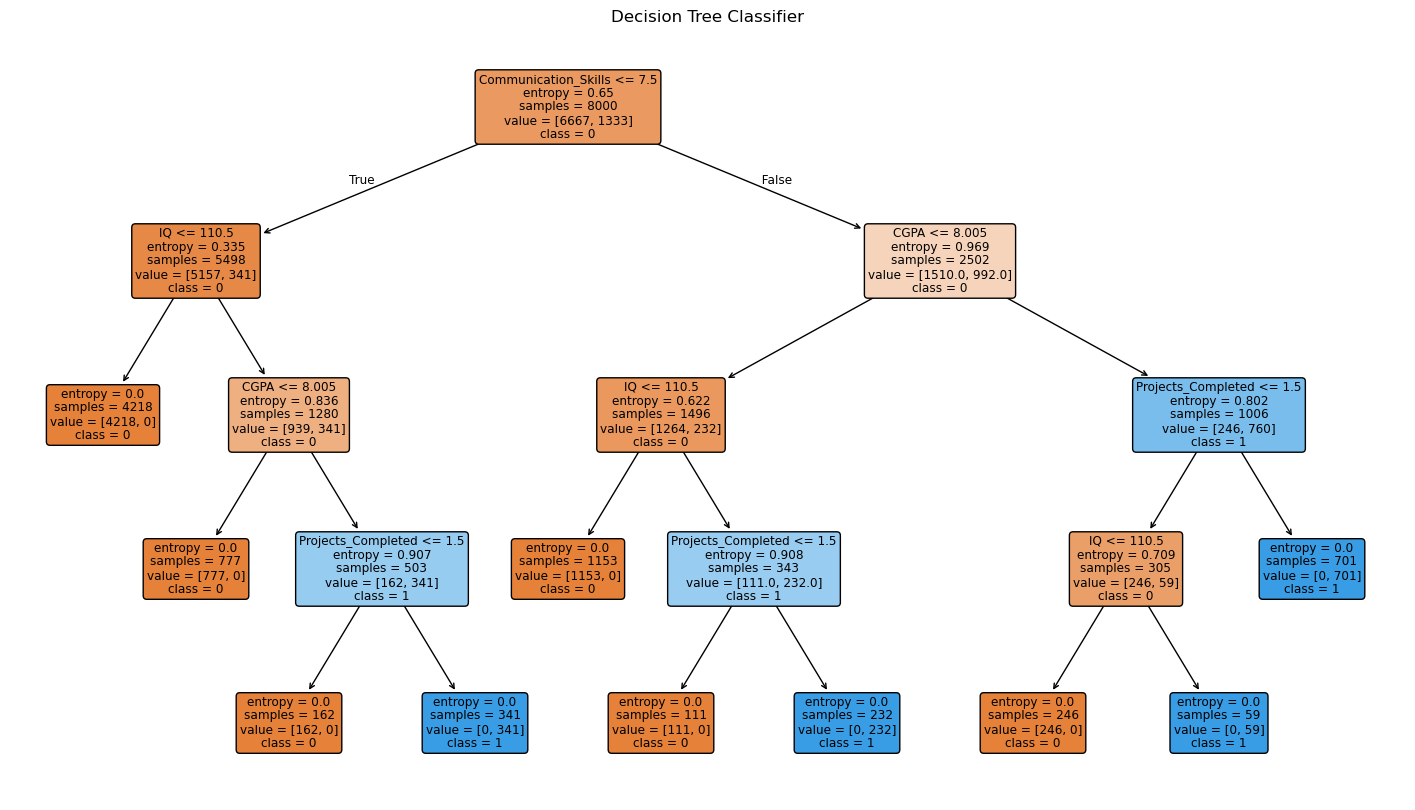

In [13]:
# Plot Decision Tree
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in model.classes_],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.show()